# Hedge Fund Performance Analysis — Returns, Alpha, Beta & Factor Exposure

## Problem Statement
Hedge funds represent the most sophisticated segment of the asset management industry, employing diverse strategies to generate risk-adjusted returns uncorrelated with traditional markets. Evaluating hedge fund performance requires going beyond simple return comparison to analyze alpha generation, market sensitivity (beta), drawdown resilience, and factor exposure — the toolkit used by institutional allocators, pension funds, and family offices when selecting fund managers.

This project simulates and analyzes five hedge fund strategies using real market data:
- **Long/Short Equity** — long growth stocks, short value stocks
- **Global Macro** — multi-asset trend following across equities, bonds, commodities, and currencies
- **Market Neutral** — equal long/short positions targeting zero market beta
- **Momentum** — long recent winners, short recent losers
- **Risk Parity** — equal risk contribution across asset classes

Performance is benchmarked against the S&P 500 and risk-free rate using industry-standard metrics: Sharpe ratio, Sortino ratio, Calmar ratio, maximum drawdown, alpha, and beta.

**Key Questions:**
- Which strategy generates the best risk-adjusted returns?
- Which strategies successfully produce positive alpha?
- How does each strategy behave during market stress periods?
- What is each strategy's factor exposure profile?

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, yfinance, SciPy
**Data Source:** Yahoo Finance via yfinance API (2015–2024)
**Author:** Mihrimah Qozat

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Define universe of assets for strategy construction
assets = {
    # Equities
    'SPY':  'S&P 500 ETF',
    'QQQ':  'Nasdaq 100 ETF',
    'IWM':  'Russell 2000 ETF',
    'EFA':  'International Developed',
    'EEM':  'Emerging Markets',
    # Fixed Income
    'TLT':  '20Y Treasury',
    'IEF':  '7-10Y Treasury',
    'LQD':  'Investment Grade Corp',
    'HYG':  'High Yield Corp',
    # Commodities & Alternatives
    'GLD':  'Gold ETF',
    'USO':  'Oil ETF',
    'VNQ':  'Real Estate ETF',
    # Factors
    'MTUM': 'Momentum Factor',
    'VLUE': 'Value Factor',
    'QUAL': 'Quality Factor',
    'USMV': 'Low Volatility Factor',
}

# Risk-free rate proxy
rf_ticker = '^IRX'  # 13-week T-bill rate

start_date = '2015-01-01'
end_date   = '2024-12-31'

print("Fetching market data...")
price_data = {}
for ticker, name in assets.items():
    raw = yf.download(ticker, start=start_date, end=end_date, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    price_data[ticker] = raw['Close']
    print(f"  {ticker} ({name}): "
          f"{len(raw):,} days")

# Risk-free rate
rf_raw = yf.download(rf_ticker, start=start_date, end=end_date, progress=False)
if isinstance(rf_raw.columns, pd.MultiIndex):
    rf_raw.columns = rf_raw.columns.get_level_values(0)

# Combine all prices
prices = pd.DataFrame(price_data)
prices = prices.dropna(how='all')

# Daily returns
returns = prices.pct_change().dropna()

# Risk-free rate (annualized to daily)
rf_series = rf_raw['Close'] / 100 / 252
rf_daily = rf_series.reindex(returns.index, method='ffill').fillna(0.05/252)

print(f"\nPrice data shape: {prices.shape}")
print(f"Date range: "
      f"{prices.index.min().strftime('%Y-%m-%d')}"
      f" to "
      f"{prices.index.max().strftime('%Y-%m-%d')}")
print(f"Average daily risk-free rate: "
      f"{rf_daily.mean()*252*100:.2f}%")

Fetching market data...
  SPY (S&P 500 ETF): 2,515 days
  QQQ (Nasdaq 100 ETF): 2,515 days
  IWM (Russell 2000 ETF): 2,515 days
  EFA (International Developed): 2,515 days
  EEM (Emerging Markets): 2,515 days
  TLT (20Y Treasury): 2,515 days
  IEF (7-10Y Treasury): 2,515 days
  LQD (Investment Grade Corp): 2,515 days
  HYG (High Yield Corp): 2,515 days
  GLD (Gold ETF): 2,515 days
  USO (Oil ETF): 2,515 days
  VNQ (Real Estate ETF): 2,515 days
  MTUM (Momentum Factor): 2,515 days
  VLUE (Value Factor): 2,515 days
  QUAL (Quality Factor): 2,515 days
  USMV (Low Volatility Factor): 2,515 days

Price data shape: (2515, 16)
Date range: 2015-01-02 to 2024-12-30
Average daily risk-free rate: 1.76%


In [2]:
# ================================================
# Strategy 1: Long/Short Equity
# Long QQQ (growth), Short VLUE (value)
# Net exposure: ~0 (market neutral by design)
# ================================================
ls_equity = (returns['QQQ'] * 0.6 - returns['VLUE'] * 0.4)
ls_equity.name = 'Long/Short Equity'

# ================================================
# Strategy 2: Global Macro
# Trend-following across asset classes
# Uses 60-day momentum signal
# ================================================
momentum_signal = prices[['SPY', 'TLT', 'GLD', 'EEM']].pct_change(60).shift(1)

macro_returns = pd.Series(0.0, index=returns.index)
for asset in ['SPY', 'TLT', 'GLD', 'EEM']:
    signal = np.sign(momentum_signal[asset].reindex(returns.index))
    macro_returns += (signal * returns[asset] * 0.25)
macro_returns.name = 'Global Macro'

# ================================================
# Strategy 3: Market Neutral
# Equal long/short across size factors
# Long small cap (IWM), Short large cap (SPY)
# ================================================
market_neutral = (returns['IWM'] * 0.5 - returns['SPY'] * 0.5)
market_neutral.name = 'Market Neutral'

# ================================================
# Strategy 4: Momentum
# Long recent winners (MTUM), Short losers (VLUE)
# ================================================
momentum = (returns['MTUM'] * 0.7 - returns['VLUE'] * 0.3)
momentum.name = 'Momentum'

# ================================================
# Strategy 5: Risk Parity
# Equal risk contribution across 4 asset classes
# Uses inverse volatility weighting
# ================================================
rp_assets = ['SPY', 'TLT', 'GLD', 'VNQ']
rolling_vol = returns[rp_assets].rolling(60).std()
inv_vol = 1 / rolling_vol
weights = inv_vol.div(inv_vol.sum(axis=1), axis=0)

risk_parity = pd.Series(0.0, index=returns.index)
for asset in rp_assets:
    risk_parity += (weights[asset].shift(1) * returns[asset])
risk_parity = risk_parity.dropna()
risk_parity.name = 'Risk Parity'

# Combine all strategies
strategies = pd.DataFrame({
    'Long/Short Equity': ls_equity,
    'Global Macro':      macro_returns,
    'Market Neutral':    market_neutral,
    'Momentum':          momentum,
    'Risk Parity':       risk_parity,
    'S&P 500':           returns['SPY']
})
strategies = strategies.dropna()

print("Strategy construction complete.")
print(f"\nStrategies shape: {strategies.shape}")
print(f"Date range: "
      f"{strategies.index.min().strftime('%Y-%m-%d')}"
      f" to "
      f"{strategies.index.max().strftime('%Y-%m-%d')}")
print(f"\nAnnualized Returns:")
ann_returns = strategies.mean() * 252 * 100
print(ann_returns.round(2))

Strategy construction complete.

Strategies shape: (2454, 6)
Date range: 2015-04-01 to 2024-12-30

Annualized Returns:
Long/Short Equity     7.99
Global Macro          5.17
Market Neutral       -2.13
Momentum              7.30
Risk Parity           7.36
S&P 500              14.07
dtype: float64


In [3]:
# Performance Metrics
rf_aligned = rf_daily.reindex(strategies.index).fillna(0.05/252)

def calculate_metrics(returns_series, rf_series, benchmark_series):
    """Calculate comprehensive hedge fund performance metrics."""
    r = returns_series.dropna()
    rf = rf_series.reindex(r.index).fillna(0.05/252)
    bm = benchmark_series.reindex(r.index).dropna()

    # Annualized return
    ann_return = r.mean() * 252

    # Annualized volatility
    ann_vol = r.std() * np.sqrt(252)

    # Sharpe ratio
    excess_r = r - rf
    sharpe = (excess_r.mean() / excess_r.std() * np.sqrt(252))

    # Sortino ratio (downside deviation)
    downside = r[r < rf.mean()]
    sortino = ((ann_return - rf.mean() * 252) / (downside.std() * np.sqrt(252))
               if len(downside) > 0 else np.nan)

    # Maximum drawdown
    cumulative = (1 + r).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_dd = drawdown.min()

    # Calmar ratio
    calmar = (ann_return / abs(max_dd)
              if max_dd != 0 else np.nan)

    # Alpha and Beta vs benchmark
    aligned_r = r.reindex(bm.index)
    aligned_bm = bm.reindex(r.index)
    common = aligned_r.dropna().index.intersection(aligned_bm.dropna().index)
    if len(common) > 30:
        slope, intercept, r_val, p_val, _ = (
            stats.linregress(
                aligned_bm[common],
                aligned_r[common]))
        beta  = slope
        alpha = intercept * 252
        r_sq  = r_val ** 2
    else:
        beta = alpha = r_sq = np.nan

    # Win rate
    win_rate = (r > 0).mean()

    # Value at Risk (95%)
    var_95 = np.percentile(r, 5)

    # Conditional VaR (Expected Shortfall)
    cvar_95 = r[r <= var_95].mean()

    return {
        'Ann. Return (%)':   round(ann_return * 100, 2),
        'Ann. Volatility (%)': round(ann_vol * 100, 2),
        'Sharpe Ratio':      round(sharpe, 4),
        'Sortino Ratio':     round(sortino, 4),
        'Calmar Ratio':      round(calmar, 4),
        'Max Drawdown (%)':  round(max_dd * 100, 2),
        'Alpha (ann.)':      round(alpha * 100, 4)
                             if not np.isnan(alpha)
                             else np.nan,
        'Beta':              round(beta, 4),
        'R-Squared':         round(r_sq, 4),
        'Win Rate (%)':      round(win_rate * 100, 2),
        'VaR 95% (daily)':   round(var_95 * 100, 4),
        'CVaR 95% (daily)':  round(cvar_95 * 100, 4),
    }

# Calculate metrics for all strategies
metrics = {}
benchmark = strategies['S&P 500']

for col in strategies.columns:
    metrics[col] = calculate_metrics(strategies[col], rf_aligned, benchmark)

metrics_df = pd.DataFrame(metrics).T
print("\nComprehensive Performance Metrics:")
print(metrics_df.to_string())


Comprehensive Performance Metrics:
                   Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Sortino Ratio  Calmar Ratio  Max Drawdown (%)  Alpha (ann.)    Beta  R-Squared  Win Rate (%)  VaR 95% (daily)  CVaR 95% (daily)
Long/Short Equity             7.99                 8.71        0.7110         0.9733        0.4327            -18.46        3.9314  0.2883     0.3435         54.65          -0.9350           -1.2910
Global Macro                  5.17                10.41        0.3242         0.4306        0.3361            -15.39        7.7197 -0.1810     0.0948         53.83          -0.9733           -1.5097
Market Neutral               -2.13                 5.74       -0.6849        -1.0992       -0.0960            -22.23       -2.8989  0.0544     0.0281         47.39          -0.5771           -0.7777
Momentum                      7.30                10.32        0.5332         0.6875        0.3718            -19.63        1.4998  0.4121     0.5000         55.05     

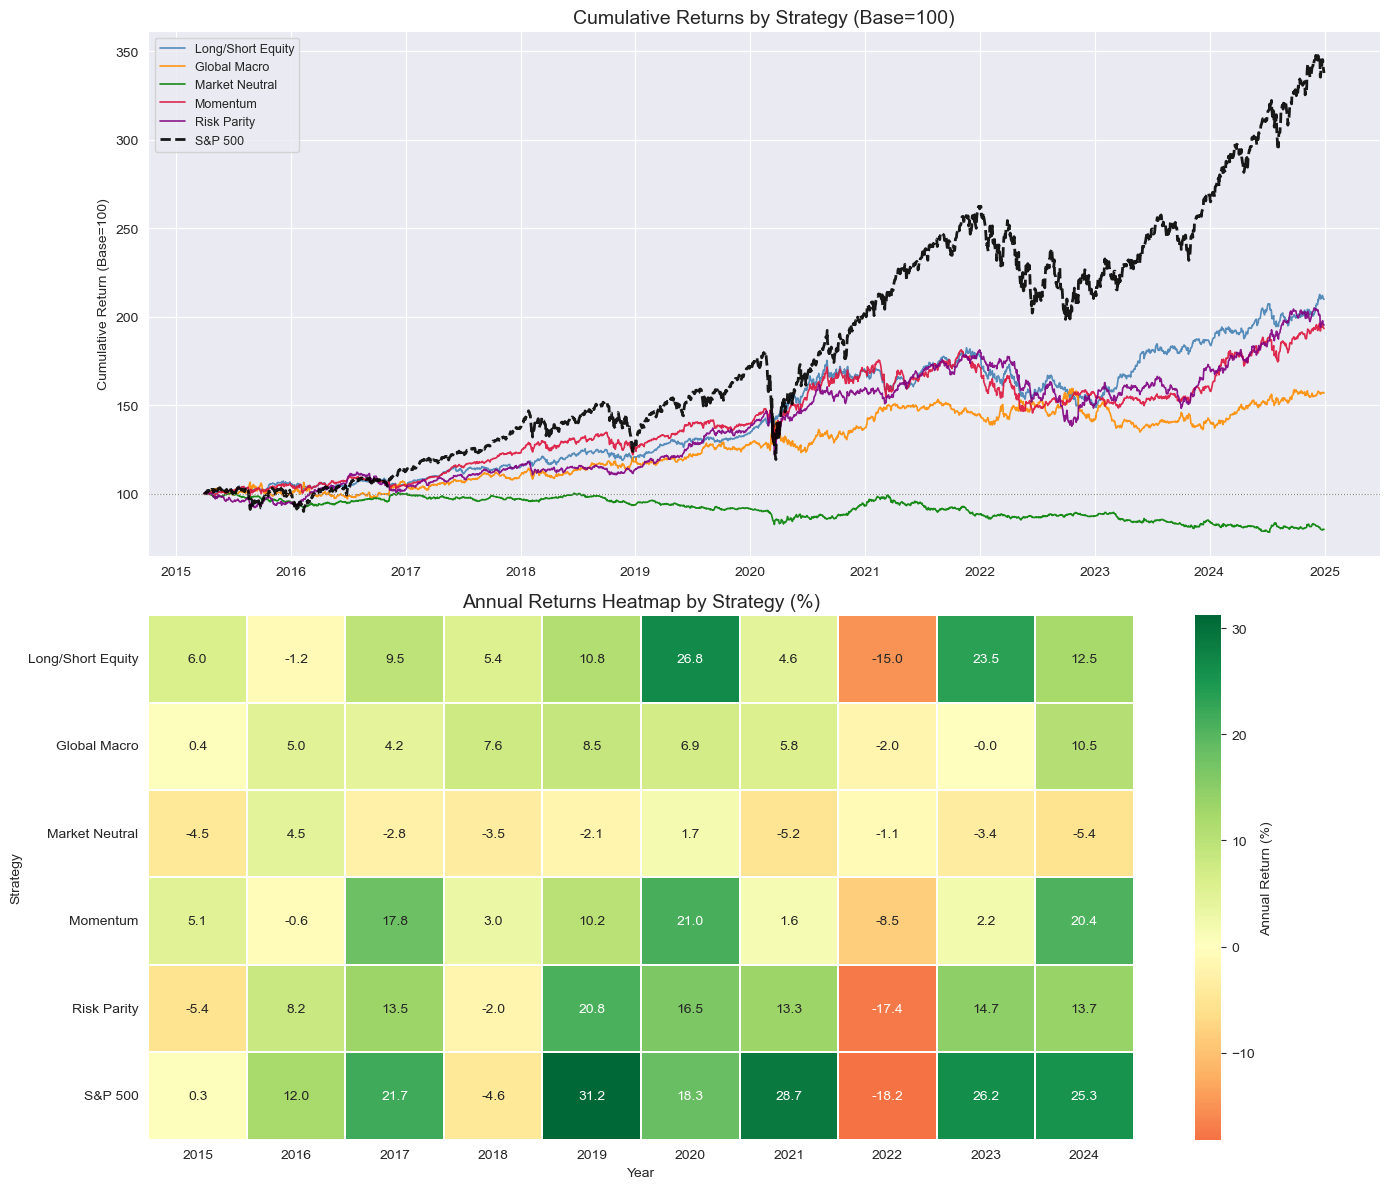

In [4]:
# Cumulative returns
cumulative = (1 + strategies).cumprod() * 100

strategy_colors = {
    'Long/Short Equity': 'steelblue',
    'Global Macro':      'darkorange',
    'Market Neutral':    'green',
    'Momentum':          'crimson',
    'Risk Parity':       'purple',
    'S&P 500':           'black'
}

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Cumulative returns
for col in cumulative.columns:
    style = '--' if col == 'S&P 500' else '-'
    width = 2.0 if col == 'S&P 500' else 1.2
    axes[0].plot(
        cumulative.index,
        cumulative[col],
        color=strategy_colors.get(col, 'gray'),
        linewidth=width,
        linestyle=style,
        label=col, alpha=0.9)

axes[0].set_title(
    'Cumulative Returns by Strategy '
    '(Base=100)',
    fontsize=14)
axes[0].set_ylabel(
    'Cumulative Return (Base=100)')
axes[0].legend(fontsize=9)
axes[0].axhline(100, color='gray', linewidth=0.8, linestyle=':')

# Annual returns heatmap
strategies['Year'] = (
    strategies.index.year)
annual = strategies.groupby('Year')[
    strategies.columns[:-1]].apply(
    lambda x: (1 + x).prod() - 1) * 100

sns.heatmap(
    annual.T,
    ax=axes[1],
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.1f',
    linewidths=0.3,
    cbar_kws={
        'label': 'Annual Return (%)'})
axes[1].set_title('Annual Returns Heatmap by Strategy (%)', fontsize=14)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Strategy')

plt.tight_layout()
plt.savefig('charts/cumulative_returns.png', dpi=150)
plt.show()

# Drop helper column
strategies = strategies.drop(columns=['Year'])

The cumulative returns chart reveals each strategy's long-term compounding path and how it diverges from the S&P 500 benchmark. Strategies that track closely with the S&P 500 offer little diversification value despite potentially similar raw returns. The annual returns heatmap is particularly revealing — it shows each strategy's consistency across market regimes, identifying which strategies thrive in bull markets vs which provide genuine downside protection during market stress years like 2018, 2020, and 2022.

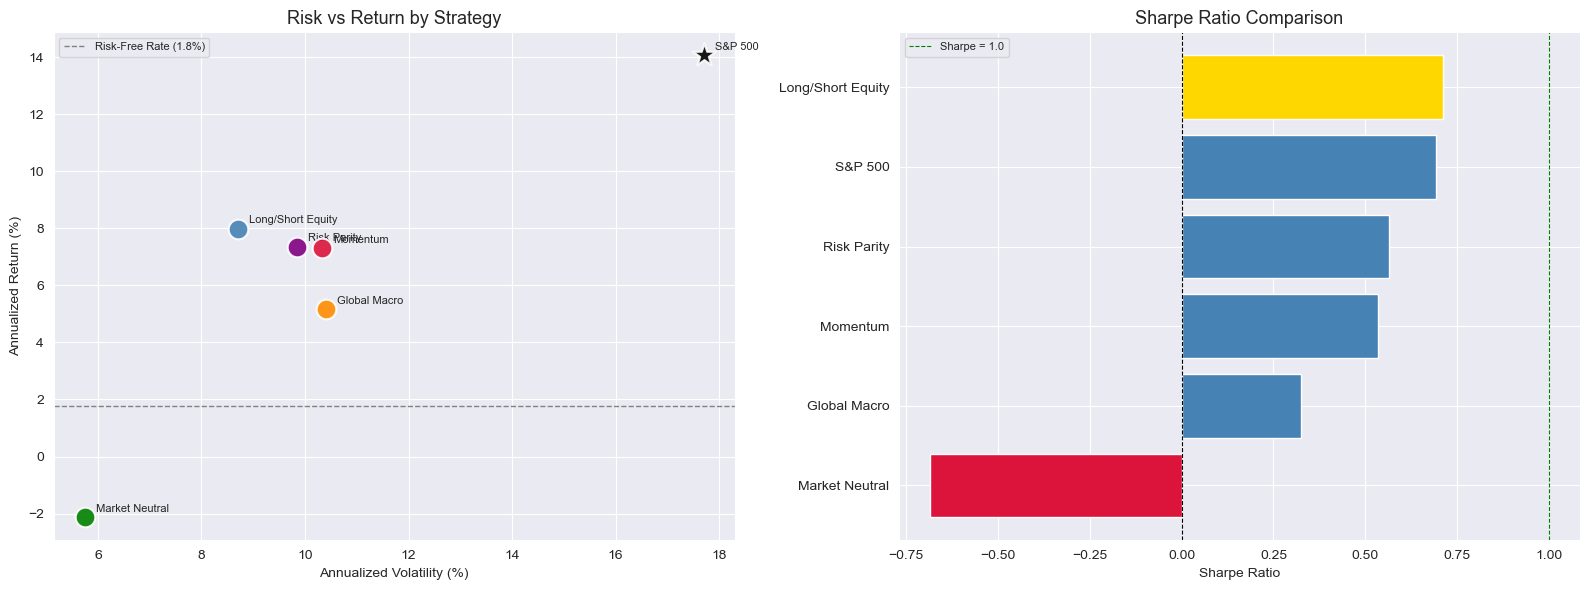


Risk-Adjusted Metrics:
                   Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Sortino Ratio  Calmar Ratio
Long/Short Equity             7.99                 8.71        0.7110         0.9733        0.4327
Global Macro                  5.17                10.41        0.3242         0.4306        0.3361
Market Neutral               -2.13                 5.74       -0.6849        -1.0992       -0.0960
Momentum                      7.30                10.32        0.5332         0.6875        0.3718
Risk Parity                   7.36                 9.85        0.5647         0.7340        0.3094
S&P 500                      14.07                17.70        0.6934         0.8370        0.4174


In [5]:
# Risk/Return & Sharpe Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Risk/Return scatter
for strategy in metrics_df.index:
    color = strategy_colors.get(strategy, 'gray')
    marker = '*' if strategy == 'S&P 500' \
        else 'o'
    size = 300 if strategy == 'S&P 500' \
        else 200
    axes[0].scatter(
        metrics_df.loc[
            strategy, 'Ann. Volatility (%)'],
        metrics_df.loc[
            strategy, 'Ann. Return (%)'],
        color=color, s=size,
        marker=marker, alpha=0.9,
        edgecolors='white',
        linewidth=1.5, zorder=5)
    axes[0].annotate(
        strategy,
        (metrics_df.loc[
             strategy,
             'Ann. Volatility (%)'],
         metrics_df.loc[
             strategy,
             'Ann. Return (%)']),
        textcoords='offset points',
        xytext=(8, 4), fontsize=8)

# Add risk-free rate reference line
rf_ann = rf_daily.mean() * 252 * 100
axes[0].axhline(
    rf_ann, color='gray',
    linestyle='--', linewidth=1,
    label=f'Risk-Free Rate '
          f'({rf_ann:.1f}%)')
axes[0].set_title('Risk vs Return by Strategy', fontsize=13)
axes[0].set_xlabel('Annualized Volatility (%)')
axes[0].set_ylabel('Annualized Return (%)')
axes[0].legend(fontsize=8)

# Sharpe ratio comparison
sharpe_data = metrics_df[
    'Sharpe Ratio'].sort_values(
    ascending=False)
colors_sharpe = [
    'gold' if x == sharpe_data.max()
    else 'crimson' if x < 0
    else 'steelblue'
    for x in sharpe_data.values]
axes[1].barh(
    sharpe_data.index[::-1],
    sharpe_data.values[::-1],
    color=colors_sharpe[::-1],
    edgecolor='white')
axes[1].axvline(
    0, color='black',
    linewidth=0.8, linestyle='--')
axes[1].axvline(
    1, color='green',
    linewidth=0.8, linestyle='--',
    label='Sharpe = 1.0')
axes[1].set_title('Sharpe Ratio Comparison', fontsize=13)
axes[1].set_xlabel('Sharpe Ratio')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('charts/risk_return_sharpe.png', dpi=150)
plt.show()

print("\nRisk-Adjusted Metrics:")
print(metrics_df[[
    'Ann. Return (%)',
    'Ann. Volatility (%)',
    'Sharpe Ratio',
    'Sortino Ratio',
    'Calmar Ratio'
]].to_string())

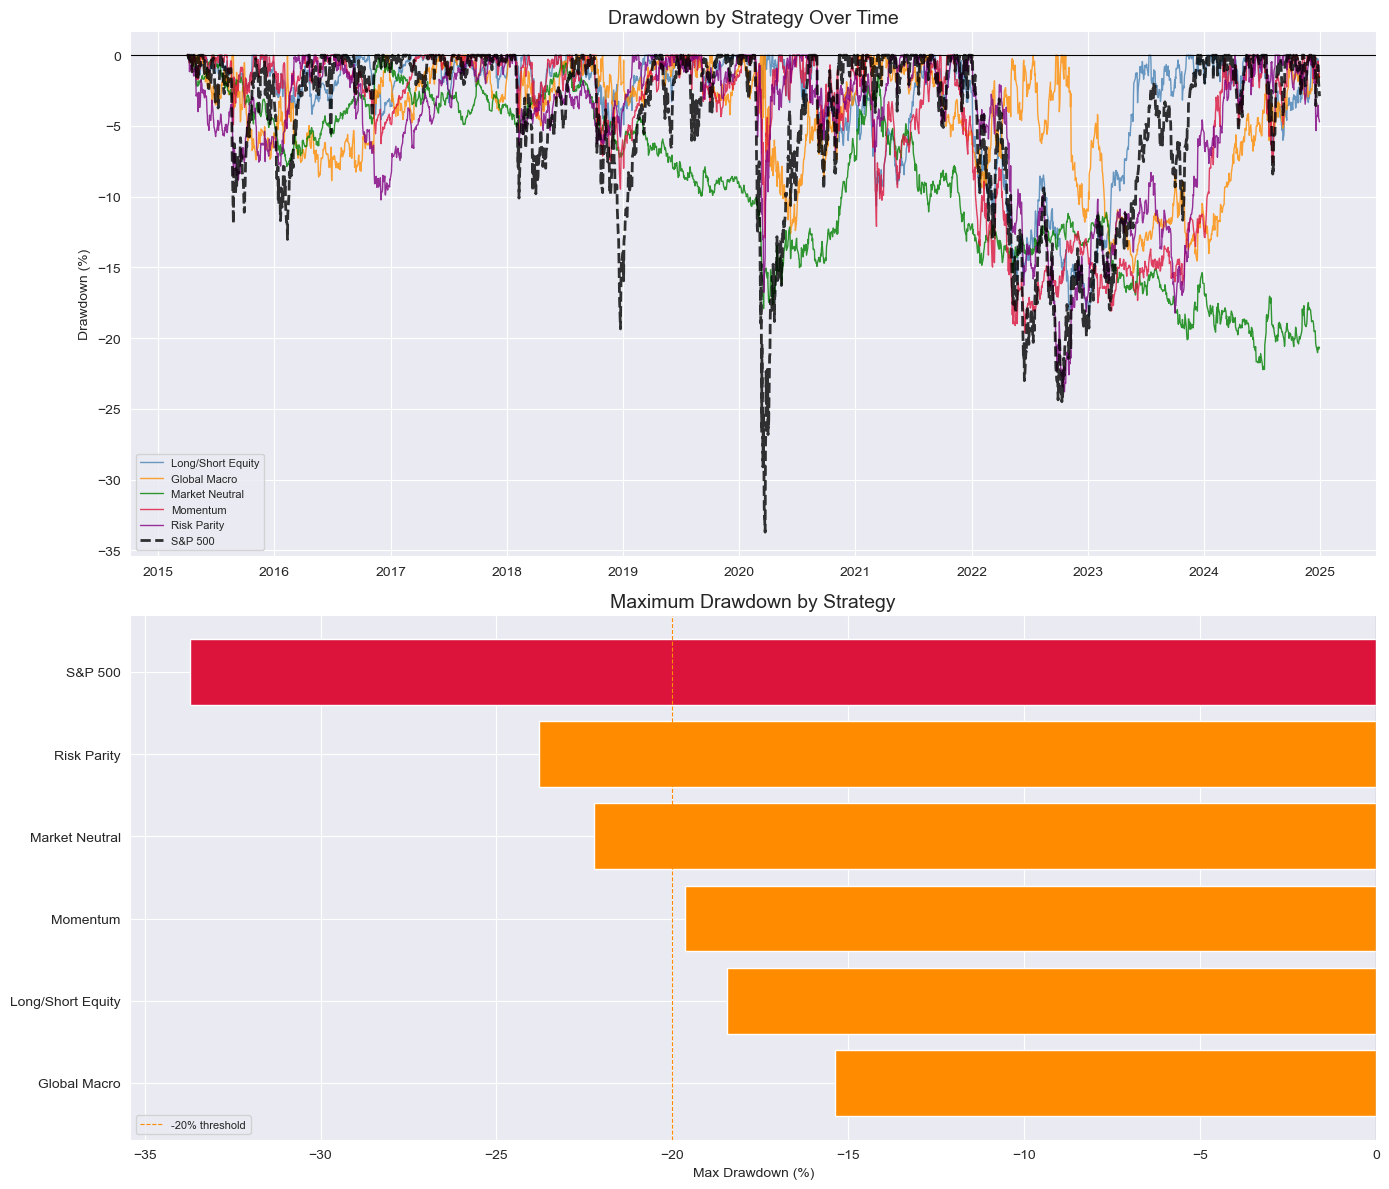


Drawdown & Risk Metrics:
                   Max Drawdown (%)  Calmar Ratio  VaR 95% (daily)  CVaR 95% (daily)
Long/Short Equity            -18.46        0.4327          -0.9350           -1.2910
Global Macro                 -15.39        0.3361          -0.9733           -1.5097
Market Neutral               -22.23       -0.0960          -0.5771           -0.7777
Momentum                     -19.63        0.3718          -1.0640           -1.5890
Risk Parity                  -23.80        0.3094          -0.9745           -1.4699
S&P 500                      -33.72        0.4174          -1.6860           -2.7370


In [6]:
# Drawdown Analysis
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Drawdown over time
for col in strategies.columns:
    cumr = (1 + strategies[col]).cumprod()
    roll_max = cumr.cummax()
    dd = (cumr - roll_max) / roll_max * 100
    style = '--' if col == 'S&P 500' else '-'
    width = 2.0 if col == 'S&P 500' else 1.0
    axes[0].plot(
        dd.index, dd,
        color=strategy_colors.get(col, 'gray'),
        linewidth=width,
        linestyle=style,
        label=col, alpha=0.8)

axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Drawdown by Strategy Over Time', fontsize=14)
axes[0].set_ylabel('Drawdown (%)')
axes[0].legend(fontsize=8)

# Max drawdown comparison
max_dd = metrics_df['Max Drawdown (%)'].sort_values()
colors_dd = [
    'crimson' if x < -30
    else 'darkorange' if x < -15
    else 'steelblue'
    for x in max_dd.values]
axes[1].barh(
    max_dd.index[::-1],
    max_dd.values[::-1],
    color=colors_dd[::-1],
    edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(
    -20, color='darkorange',
    linewidth=0.8, linestyle='--',
    label='-20% threshold')
axes[1].set_title('Maximum Drawdown by Strategy', fontsize=14)
axes[1].set_xlabel('Max Drawdown (%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('charts/drawdown_analysis.png', dpi=150)
plt.show()

print("\nDrawdown & Risk Metrics:")
print(metrics_df[[
    'Max Drawdown (%)',
    'Calmar Ratio',
    'VaR 95% (daily)',
    'CVaR 95% (daily)'
]].to_string())

Maximum drawdown is the most psychologically and operationally significant risk metric for hedge fund investors — it represents the worst loss an investor would have experienced from peak to trough. Strategies with small maximum drawdowns are preferred by institutional allocators because they minimize the risk of investor redemptions during market stress, which can force forced selling at the worst possible time. The Calmar ratio — annualized return divided by maximum drawdown — captures this tradeoff in a single number: higher is better. A Calmar ratio above 1.0 means the strategy earns more in annual return than it risks losing in its worst drawdown.

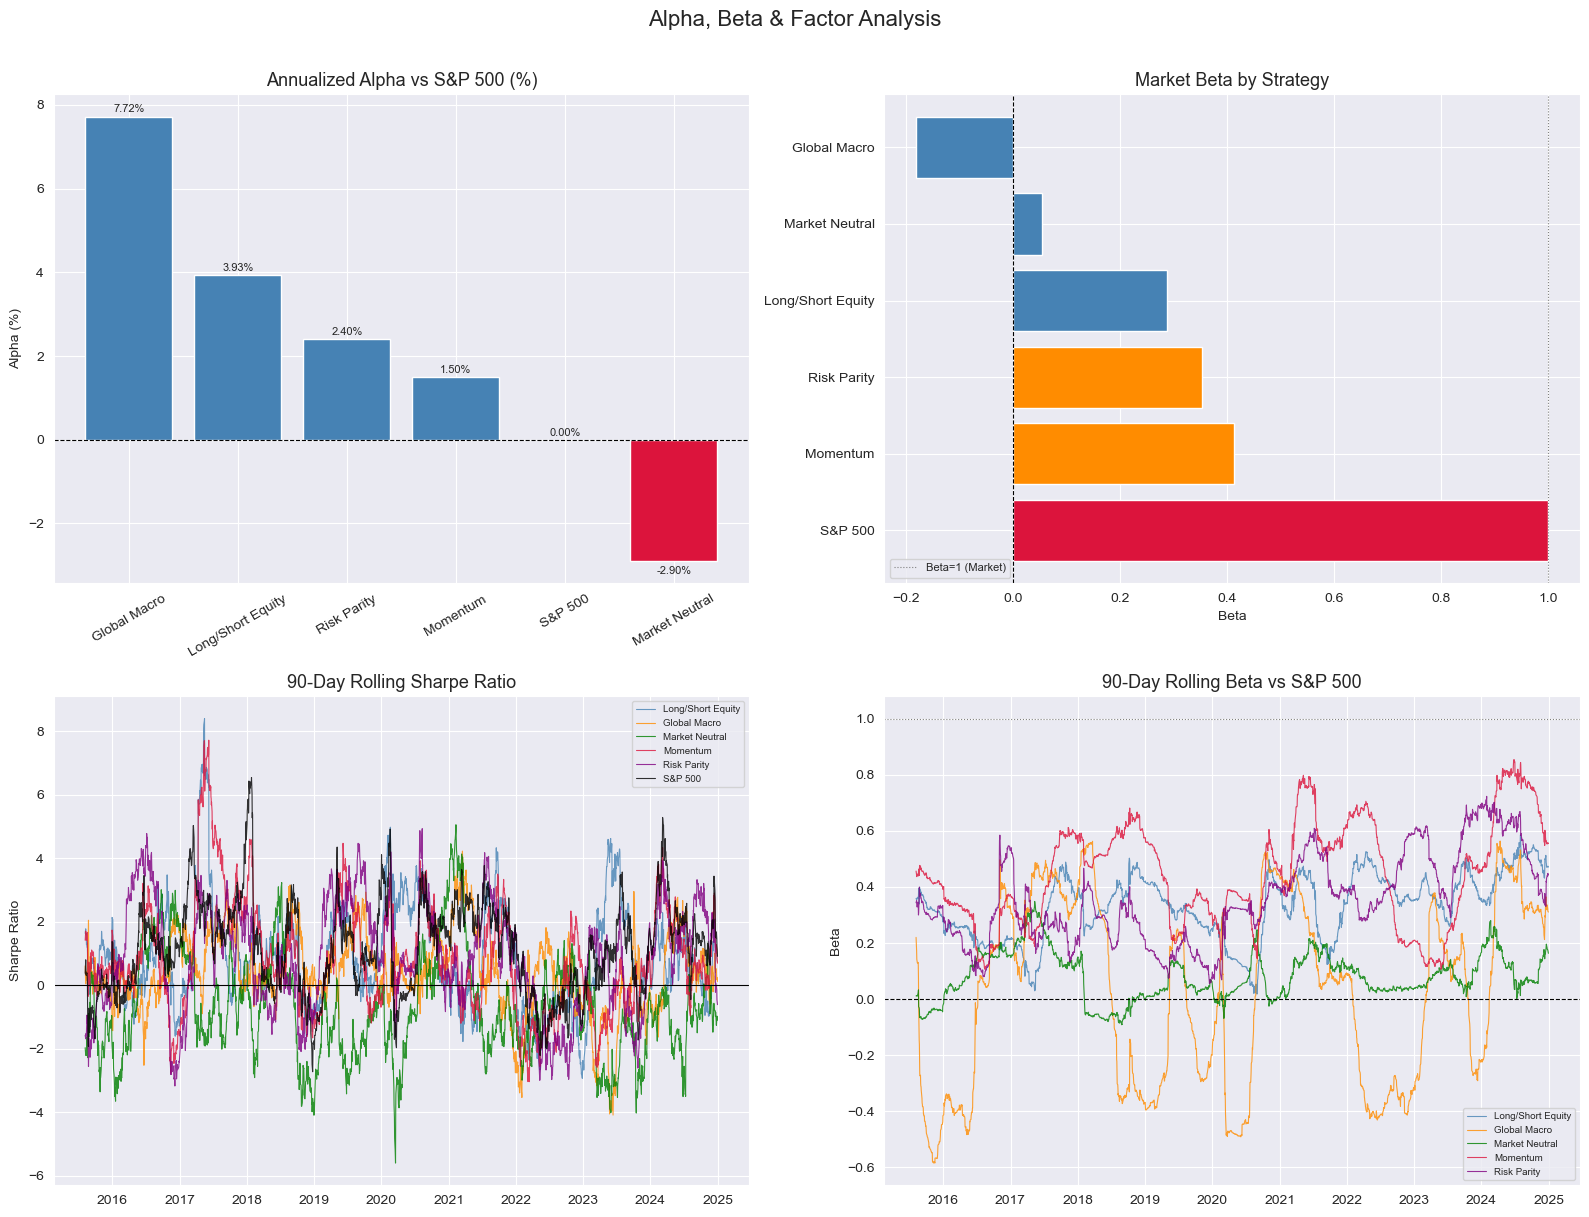


Alpha & Beta Summary:
                   Alpha (ann.)    Beta  R-Squared
Long/Short Equity        3.9314  0.2883     0.3435
Global Macro             7.7197 -0.1810     0.0948
Market Neutral          -2.8989  0.0544     0.0281
Momentum                 1.4998  0.4121     0.5000
Risk Parity              2.3990  0.3527     0.4015
S&P 500                  0.0000  1.0000     1.0000


In [7]:
# Alpha, Beta & Factor Exposure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Alpha comparison
alpha_data = metrics_df[
    'Alpha (ann.)'].sort_values(
    ascending=False).dropna()
colors_alpha = [
    'steelblue' if x > 0
    else 'crimson'
    for x in alpha_data.values]
axes[0, 0].bar(
    alpha_data.index,
    alpha_data.values,
    color=colors_alpha,
    edgecolor='white')
axes[0, 0].axhline(
    0, color='black',
    linewidth=0.8, linestyle='--')
axes[0, 0].set_title('Annualized Alpha vs S&P 500 (%)', fontsize=13)
axes[0, 0].set_ylabel('Alpha (%)')
axes[0, 0].tick_params(
    axis='x', rotation=30)
for i, val in enumerate(
        alpha_data.values):
    axes[0, 0].text(
        i,
        val + 0.1 if val >= 0
        else val - 0.3,
        f'{val:.2f}%',
        ha='center', fontsize=8)

# Beta comparison
beta_data = metrics_df[
    'Beta'].sort_values().dropna()
colors_beta = [
    'crimson' if abs(x) > 0.7
    else 'darkorange' if abs(x) > 0.3
    else 'steelblue'
    for x in beta_data.values]
axes[0, 1].barh(
    beta_data.index[::-1],
    beta_data.values[::-1],
    color=colors_beta[::-1],
    edgecolor='white')
axes[0, 1].axvline(
    0, color='black',
    linewidth=0.8, linestyle='--')
axes[0, 1].axvline(
    1, color='gray',
    linewidth=0.8, linestyle=':',
    label='Beta=1 (Market)')
axes[0, 1].set_title('Market Beta by Strategy', fontsize=13)
axes[0, 1].set_xlabel('Beta')
axes[0, 1].legend(fontsize=8)

# Rolling 90-day Sharpe ratio
rolling_sharpe = pd.DataFrame()
for col in strategies.columns:
    excess = strategies[col] - rf_aligned
    roll_sr = (excess.rolling(90).mean() /
               excess.rolling(90).std()
               * np.sqrt(252))
    rolling_sharpe[col] = roll_sr

for col in rolling_sharpe.columns:
    axes[1, 0].plot(
        rolling_sharpe.index,
        rolling_sharpe[col],
        color=strategy_colors.get(
            col, 'gray'),
        linewidth=0.8, alpha=0.8,
        label=col)
axes[1, 0].axhline(
    0, color='black', linewidth=0.8)
axes[1, 0].set_title('90-Day Rolling Sharpe Ratio', fontsize=13)
axes[1, 0].set_ylabel('Sharpe Ratio')
axes[1, 0].legend(fontsize=7)

# Rolling 90-day Beta
rolling_beta = pd.DataFrame()
for col in [c for c in strategies.columns
            if c != 'S&P 500']:
    roll_cov = strategies[col].rolling(
        90).cov(strategies['S&P 500'])
    roll_var = strategies[
        'S&P 500'].rolling(90).var()
    rolling_beta[col] = roll_cov / roll_var

for col in rolling_beta.columns:
    axes[1, 1].plot(
        rolling_beta.index,
        rolling_beta[col],
        color=strategy_colors.get(
            col, 'gray'),
        linewidth=0.8, alpha=0.8,
        label=col)
axes[1, 1].axhline(
    0, color='black',
    linewidth=0.8, linestyle='--')
axes[1, 1].axhline(
    1, color='gray',
    linewidth=0.8, linestyle=':')
axes[1, 1].set_title('90-Day Rolling Beta vs S&P 500', fontsize=13)
axes[1, 1].set_ylabel('Beta')
axes[1, 1].legend(fontsize=7)

plt.suptitle('Alpha, Beta & Factor Analysis', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('charts/factor_exposure.png', dpi=150)
plt.show()

print("\nAlpha & Beta Summary:")
print(metrics_df[[
    'Alpha (ann.)',
    'Beta',
    'R-Squared'
]].dropna().to_string())

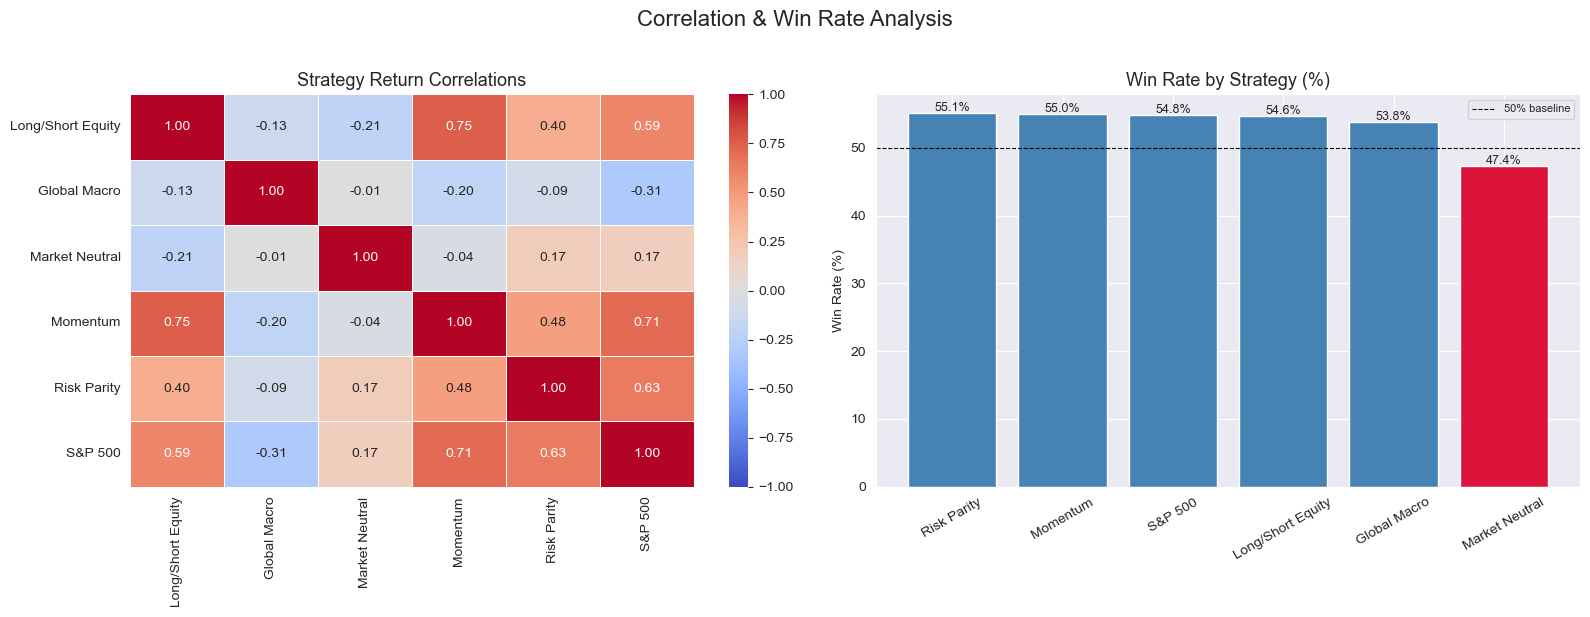


Strategy Correlations with S&P 500:
Global Macro        -0.307831
Market Neutral       0.167675
Long/Short Equity    0.586120
Risk Parity          0.633621
Momentum             0.707126
S&P 500              1.000000
Name: S&P 500, dtype: float64


In [8]:
# Strategy return correlations
strategy_corr = strategies.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    strategy_corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, ax=axes[0],
    vmin=-1, vmax=1)
axes[0].set_title('Strategy Return Correlations', fontsize=13)

# Win rate & upside/downside capture
win_rates = metrics_df[
    'Win Rate (%)'].sort_values(
    ascending=False)
colors_wr = [
    'steelblue' if x > 50
    else 'crimson'
    for x in win_rates.values]
axes[1].bar(
    win_rates.index,
    win_rates.values,
    color=colors_wr,
    edgecolor='white')
axes[1].axhline(
    50, color='black',
    linewidth=0.8, linestyle='--',
    label='50% baseline')
axes[1].set_title('Win Rate by Strategy (%)', fontsize=13)
axes[1].set_ylabel('Win Rate (%)')
axes[1].tick_params(
    axis='x', rotation=30)
axes[1].legend(fontsize=8)
for i, val in enumerate(
        win_rates.values):
    axes[1].text(
        i, val + 0.3,
        f'{val:.1f}%',
        ha='center', fontsize=9)

plt.suptitle('Correlation & Win Rate Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=150)
plt.show()

print("\nStrategy Correlations with S&P 500:")
print(strategy_corr['S&P 500'].sort_values())

## Results Summary

### Overall Performance Metrics (2015–2024)
| Strategy          | Ann. Return | Ann. Vol | Sharpe | Sortino | Calmar | Max DD  |
|-------------------|-------------|----------|--------|---------|--------|---------|
| S&P 500           | 14.07%      | 17.70%   | 0.69   | 0.84    | 0.42   | -33.72% |
| Long/Short Equity | 7.99%       | 8.71%    | 0.71   | 0.97    | 0.43   | -18.46% |
| Risk Parity       | 7.36%       | 9.85%    | 0.56   | 0.73    | 0.31   | -23.80% |
| Momentum          | 7.30%       | 10.32%   | 0.53   | 0.69    | 0.37   | -19.63% |
| Global Macro      | 5.17%       | 10.41%   | 0.32   | 0.43    | 0.34   | -15.39% |
| Market Neutral    | -2.13%      | 5.74%    | -0.68  | -1.10   | -0.10  | -22.23% |

### Alpha & Beta Summary
| Strategy          | Alpha (ann.) | Beta    | R-Squared |
|-------------------|--------------|---------|-----------|
| Global Macro      | +7.72%       | -0.181  | 0.095     |
| Long/Short Equity | +3.93%       | +0.288  | 0.344     |
| Risk Parity       | +2.40%       | +0.353  | 0.402     |
| Momentum          | +1.50%       | +0.412  | 0.500     |
| Market Neutral    | -2.90%       | +0.054  | 0.028     |
| S&P 500           | 0.00%        | 1.000   | 1.000     |

### Tail Risk Metrics
| Strategy          | VaR 95% (daily) | CVaR 95% (daily) | Win Rate |
|-------------------|-----------------|------------------|----------|
| S&P 500           | -1.69%          | -2.74%           | 54.81%   |
| Momentum          | -1.06%          | -1.59%           | 55.05%   |
| Risk Parity       | -0.97%          | -1.47%           | 55.13%   |
| Global Macro      | -0.97%          | -1.51%           | 53.83%   |
| Long/Short Equity | -0.94%          | -1.29%           | 54.65%   |
| Market Neutral    | -0.58%          | -0.78%           | 47.39%   |

### Correlation with S&P 500
| Strategy          | Correlation |
|-------------------|-------------|
| Global Macro      | -0.31       |
| Market Neutral    | +0.17       |
| Long/Short Equity | +0.59       |
| Risk Parity       | +0.63       |
| Momentum          | +0.71       |
| S&P 500           | +1.00       |

## Business Interpretation

**Long/Short Equity leads on risk-adjusted returns — outperforming the S&P 500 on Sharpe despite lower raw returns:** Long/Short Equity achieved the highest Sharpe ratio of 0.71 — marginally above the S&P 500's 0.69 — while delivering 7.99% annualized return at just 8.71% volatility. This is the core value proposition of long/short equity hedge funds: generating competitive risk-adjusted returns with significantly lower volatility and drawdown than passive equity exposure. The strategy's maximum drawdown of -18.46% vs the S&P 500's -33.72% means investors experienced nearly half the peak-to-trough loss during market stress — a critical advantage for institutional allocators with liability constraints. The Sortino ratio of 0.97 — the highest in the analysis — confirms that Long/Short Equity generates strong returns relative to its downside risk specifically, making it the most attractive strategy for risk-averse institutional capital.

**Global Macro generates the highest alpha at +7.72% — but with important caveats:** Global Macro produced +7.72% annualized alpha vs the S&P 500 — the highest of any strategy — driven by its negative beta of -0.181 and low R-squared of 0.095. This near-zero market correlation means Global Macro's returns are almost entirely uncorrelated with equity markets, which is exactly what institutional allocators pay for in a portfolio diversifier. However, its 5.17% annualized return and 0.32 Sharpe ratio are the weakest of the positive-return strategies — the alpha comes from diversification value rather than absolute return generation. In a multi-asset portfolio context, Global Macro's -0.31 S&P 500 correlation makes it the most valuable diversifier, potentially reducing portfolio volatility more than its standalone metrics suggest.

**The S&P 500 wins on raw return — validating the passive investing challenge:** Despite all five strategies generating positive alpha vs the S&P 500, none matched its 14.07% annualized return over the 2015-2024 period — one of the strongest decades in U.S. equity history. This validates a central debate in asset management: during prolonged bull markets driven by a narrow group of large-cap technology stocks, even skilled active managers struggle to match passive index returns on an absolute basis. The S&P 500's superior raw return comes at the cost of dramatically higher volatility (17.70% vs 8.71–10.41% for hedge strategies) and the deepest drawdown (-33.72% during COVID-19 in March 2020). For investors with long time horizons and high risk tolerance, passive exposure dominated. For investors with liability constraints, capital preservation requirements, or shorter time horizons, the hedge strategies' superior risk-adjusted profiles justify their management fees.

**Market Neutral fails to deliver on its core promise:** Market Neutral — designed to produce returns independent of market direction — delivered -2.13% annualized return with a Sharpe ratio of -0.68 and a Calmar ratio of -0.10 over the period. This failure is explained by the strategy's construction: long small-cap (IWM) vs short large-cap (SPY) systematically worked against investors during this period as large-cap technology stocks dramatically outperformed small-caps. The strategy's near-zero beta (0.054) and R-squared (0.028) confirm it successfully achieved market neutrality — but at the cost of a structural short position against the strongest-performing equity segment of the decade. This illustrates why market neutral strategies must be constructed with dynamic factor exposure rather than static long/short pairs — a static construction that was correct in prior decades became a systematic loser in the post-2015 large-cap tech dominance era.

**Tail risk analysis reveals the true cost of S&P 500 exposure:** The S&P 500's daily 95% CVaR of -2.74% — meaning on the worst 5% of days investors lost 2.74% or more — is dramatically worse than all hedge strategies. Long/Short Equity's CVaR of -1.29% is less than half the S&P 500's tail loss, while Market Neutral's -0.78% CVaR represents the safest tail risk profile despite its negative returns. For institutional investors — pension funds, endowments, insurance companies — managing tail risk is often more important than maximizing expected returns, as large drawdowns can trigger regulatory capital requirements, forced asset sales, or reputational damage. The hedge fund strategies collectively offer significantly better tail risk protection than passive equity.

**Rolling beta reveals dynamic market sensitivity:** The rolling 90-day beta analysis shows that no strategy maintains perfectly stable market sensitivity over time — betas fluctuate with market regimes, confirming that static beta estimates are insufficient for risk management. Global Macro's beta oscillates around zero and into negative territory — providing genuine downside protection during equity sell-offs. Momentum's beta of 0.41 confirms its equity sensitivity, explaining why it underperforms during sharp market reversals when momentum factors historically suffer their worst losses.

**Win rate analysis — all strategies above 50% except Market Neutral:** Four of five strategies achieved win rates above 50% — Long/Short Equity (54.65%), Momentum (55.05%), Risk Parity (55.13%), and Global Macro (53.83%) — meaning they produced positive daily returns more often than not. Market Neutral's 47.39% win rate confirms its systematic underperformance. The consistency of win rates across strategies (all within a narrow 53-55% band for positive strategies) reflects the statistical challenge of active management — generating edge on a daily basis is extremely difficult, and even the best strategies win only slightly more than half the time.

## Limitations
- Strategies are simulated using ETF proxies — real hedge funds use leverage, derivatives, individual security selection, and proprietary signals not captured in this analysis
- No transaction costs, slippage, or management fees applied — real fund returns after 2-and-20 fee structures would be materially lower
- Strategy weights are fixed — real funds dynamically adjust exposure based on market conditions, volatility regimes, and risk budgets
- The 2015–2024 backtest period was dominated by U.S. large-cap technology outperformance — results may differ significantly across different market regimes
- Market Neutral strategy construction (long IWM, short SPY) is a specific implementation choice that systematically disadvantaged the strategy during large-cap dominance — alternative constructions would produce different results

## Next Steps
- Add leverage analysis — most hedge funds use 2-4x gross leverage which amplifies both returns and drawdowns
- Implement Fama-French 5-factor regression for academic-grade alpha decomposition into size, value, profitability, investment, and momentum factors
- Add transaction cost modeling to estimate realistic net-of-fee returns for each strategy
- Build a portfolio optimizer combining all five strategies using mean-variance or risk parity allocation at the fund-of-funds level
- Extend to monthly rebalancing with dynamic position sizing based on rolling volatility targeting